In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from tqdm import trange
import matplotlib.ticker as ticker

#DATA_PATH1 = "../../0-download-inputs/data-files/"

DATA_PATH2 = "../../flatten/processed-data/"
#DATA_PATH3 = "../../18-Y2H-data/processed-data/"
#ABUNDANCE  = "../../0-download-inputs/data-files/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [2]:
# load the datasets with node centrality information and get nodes in both
#ms_nodes = pd.read_pickle(f"{DATA_PATH2}20251023-s288c-annotated-PPI-net.pkl")
#y2h_nodes = pd.read_csv(f"{DATA_PATH3}Y2H-s288c-step18.csv")
nodes = pd.read_pickle(f"{DATA_PATH2}20251023-s288c-annotated-PPI-net.pkl")

#y2h_nodes = y2h_nodes.merge(abundance_df, on="node", how="left")

#shared_nodes = set(ms_nodes["node"]) & set(y2h_nodes["node"])
#print (f"A total of {len(shared_nodes)} nodes are shared between the MS and Y2H networks")
#list(nodes.columns)

In [3]:
# Filter nodes to remove proteins with low pLDDT and/or are membrane proteins (TM) with/without signal peptide (SP)
filtered_nodes = nodes[
    (nodes['mean_plddt'] >= 70) &
    (~nodes['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()

# Print stats to for nodes
print(f"Original rows: {len(nodes)}")
print(f"Filtered rows: {len(filtered_nodes)}")

Original rows: 3927
Filtered rows: 2466


In [4]:
# determine which nodes are hubs based on percentile cutoff for betweenness_centrality
cut = 0.10
ms_threshold = filtered_nodes['betweenness_centrality'].quantile(1 - cut)
ms_hubs     = filtered_nodes[filtered_nodes['betweenness_centrality'] >= ms_threshold]
ms_nothub   = filtered_nodes[filtered_nodes['betweenness_centrality'] <  ms_threshold]

#y2h_threshold = filtered_nodes['Y2H_degree_centrality'].quantile(1 - cut)
#y2h_hubs      = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] >= y2h_threshold]
#y2h_nothub    = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] <  y2h_threshold]

print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")
#print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in MS data is 0.00203; there are 247 hubs and 2219 non hubs


In [5]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid large memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

def clean_values(s):
    return s.replace([np.inf, -np.inf], np.nan).dropna()

# Only remove inf/nan — DO NOT require > 0
ms_hub_vals    = ms_hubs["Ghosh-Dill-dG"].replace([np.inf, -np.inf], np.nan).dropna()
ms_nothub_vals = ms_nothub["Ghosh-Dill-dG"].replace([np.inf, -np.inf], np.nan).dropna()
#y2h_nothub_vals = y2h_nothub["Ghosh-Dill-dG"]
#y2h_hub_vals    = y2h_hubs["Ghosh-Dill-dG"]

# Groups: (label, data, color)
groups = [
    ("MS hubs",      ms_hub_vals,     MS_COLOR),
    ("MS non-hubs",  ms_nothub_vals,  MS_COLOR),
]

# -------------------------------------------------------
# 4. Compute bootstrapped medians + CIs
# -------------------------------------------------------
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:14<00:00, 68350.82it/s]


MS hubs: median=-11.30, 95% CI=(-12.28, -10.53), n=247)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:34<00:00, 29110.65it/s]

MS non-hubs: median=-10.46, 95% CI=(-10.66, -10.22), n=2218)


In [6]:
# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="two-sided")

# Y2H: hubs vs non-hubs
#y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on Ghosh-Dill-dG ===")

print("\nMS hubs vs MS non-hubs")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on Ghosh-Dill-dG ===

MS hubs vs MS non-hubs
n(hubs) = 247, n(non-hubs) = 2218
median(hubs) = -11.30, median(non-hubs) = -10.46
U = 244483.00, p = 0.005527


/tmp/ipykernel_17906/3683149125.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


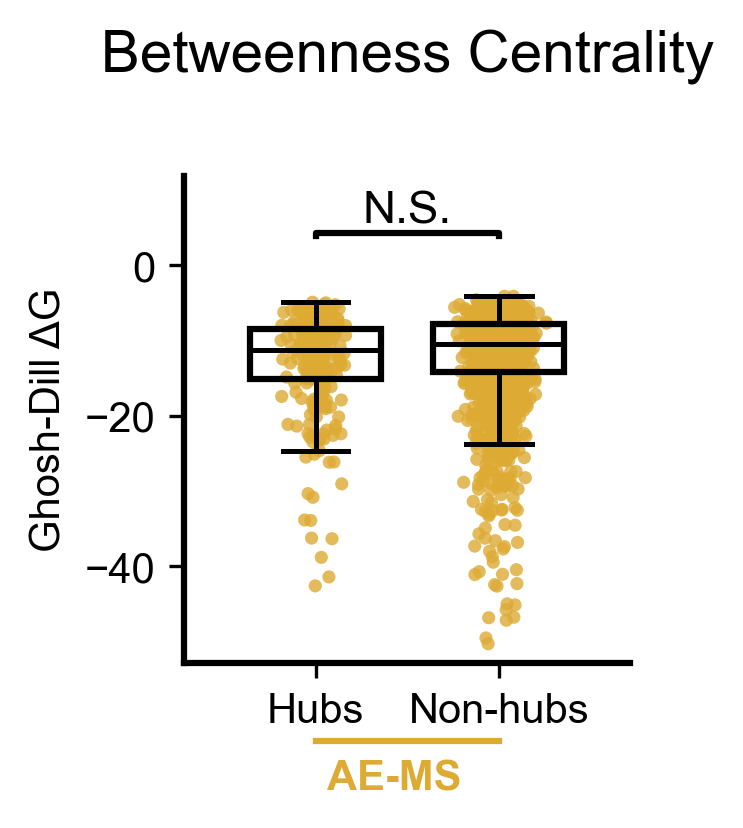

In [7]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals   = [ms_hub_vals, ms_nothub_vals]
group_colors = [MS_COLOR,    MS_COLOR]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Hubs", "Non-hubs"],
    positions=[1, 1.7],   
    widths=0.5,             
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
#ax.set_yscale("log")
#ax.set_ylim(1, 1e7)

ax.set_ylabel("Ghosh-Dill ΔG")
ax.set_title("Betweenness Centrality")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(ms_hub_vals.min(), ms_nothub_vals.min())
y_max = max(ms_hub_vals.max(), ms_nothub_vals.max())

# Significance bracket slightly above the highest data point
bracket_y = y_max + 8

# IMPORTANT: set ylim AFTER computing bracket_y
ax.set_ylim(y_min * 1.05, bracket_y + 8)

# Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")

# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.16, -0.16],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)
ax.text(
    1.3, -0.20, "AE-MS",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}supp2-1.svg")
plt.show()

In [8]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid large memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

def clean_values(s):
    return s.replace([np.inf, -np.inf], np.nan).dropna()

# multiply cagiada-dG by -1) ===
ms_hubs["cagiada-dG"]    = -ms_hubs["cagiada-dG"]
ms_nothub["cagiada-dG"]  = -ms_nothub["cagiada-dG"]
# Only remove inf/nan — DO NOT require > 0
ms_hub_vals    = ms_hubs["cagiada-dG"].replace([np.inf, -np.inf], np.nan).dropna()
ms_nothub_vals = ms_nothub["cagiada-dG"].replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("MS hubs",      ms_hub_vals,     MS_COLOR),
    ("MS non-hubs",  ms_nothub_vals,  MS_COLOR),
]

# -------------------------------------------------------
# 4. Compute bootstrapped medians + CIs
# -------------------------------------------------------
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

/tmp/ipykernel_17906/32630458.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ms_hubs["cagiada-dG"]    = -ms_hubs["cagiada-dG"]
/tmp/ipykernel_17906/32630458.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ms_nothub["cagiada-dG"]  = -ms_nothub["cagiada-dG"]
Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:14<00:00, 68124.96it/s]


MS hubs: median=-21.41, 95% CI=(-22.98, -19.59), n=247)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:35<00:00, 28117.91it/s]

MS non-hubs: median=-19.26, 95% CI=(-19.90, -18.53), n=2218)


In [9]:
# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on cagiada-dG ===")

print("\nMS hubs vs MS non-hubs")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on cagiada-dG ===

MS hubs vs MS non-hubs
n(hubs) = 247, n(non-hubs) = 2218
median(hubs) = -21.41, median(non-hubs) = -19.26
U = 238465.00, p = 0.0008325


/tmp/ipykernel_17906/1620398433.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


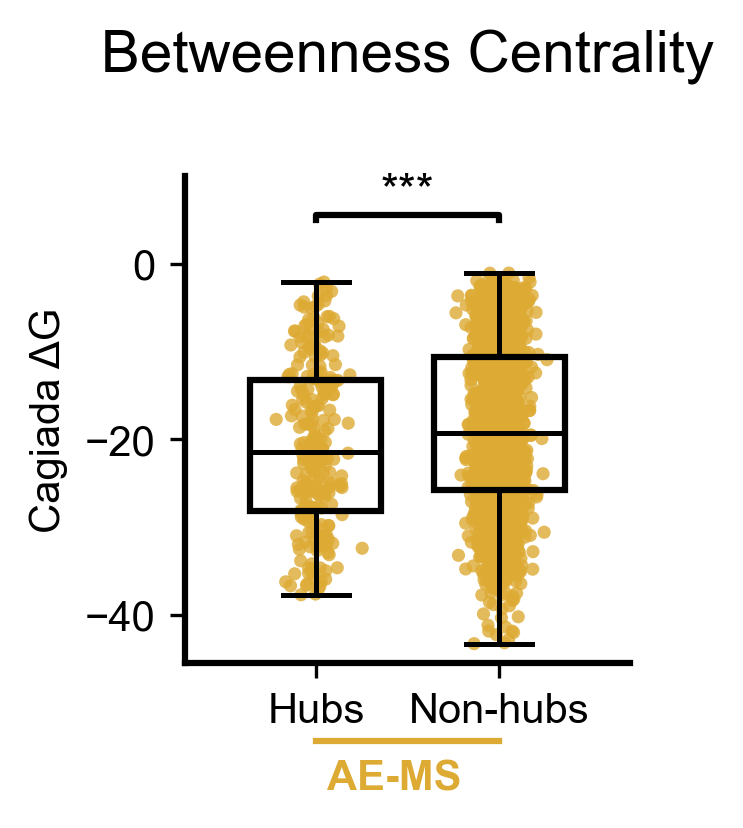

In [10]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals   = [ms_hub_vals, ms_nothub_vals]
group_colors = [MS_COLOR,    MS_COLOR]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Hubs", "Non-hubs"],
    positions=[1, 1.7],   
    widths=0.5,             
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
#ax.set_yscale("log")
#ax.set_ylim(1, 1e7)

ax.set_ylabel("Cagiada ΔG")
ax.set_title("Betweenness Centrality")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(ms_hub_vals.min(), ms_nothub_vals.min())
y_max = 10
ax.set_ylim(y_min * 1.05, y_max)   # 5% padding at bottom, 0 at top

# Place significance bracket at a fixed, nice height just above 0
bracket_y = 5  # you can adjust: -1, -3, -5 depending on taste
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "***")

# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.16, -0.16],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)
ax.text(
    1.3, -0.20, "AE-MS",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}supp2-2.svg")
plt.show()

In [11]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid large memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

def clean_values(s):
    return s.replace([np.inf, -np.inf], np.nan).dropna()

# Only remove inf/nan — DO NOT require > 0
ms_hub_vals    = ms_hubs["Rosetta_best_total_score"].replace([np.inf, -np.inf], np.nan).dropna()
ms_nothub_vals = ms_nothub["Rosetta_best_total_score"].replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("MS hubs",      ms_hub_vals,     MS_COLOR),
    ("MS non-hubs",  ms_nothub_vals,  MS_COLOR),
]

# -------------------------------------------------------
# 4. Compute bootstrapped medians + CIs
# -------------------------------------------------------
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:14<00:00, 66827.58it/s]


MS hubs: median=-1225.07, 95% CI=(-1305.52, -1119.20), n=247)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:34<00:00, 28841.78it/s]


MS non-hubs: median=-1075.73, 95% CI=(-1109.71, -1035.78), n=2218)


In [12]:
# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="two-sided")

# Y2H: hubs vs non-hubs
#y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on Rosetta_best_total_score ===")

print("\nMS hubs vs MS non-hubs")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on Rosetta_best_total_score ===

MS hubs vs MS non-hubs
n(hubs) = 247, n(non-hubs) = 2218
median(hubs) = -1225.07, median(non-hubs) = -1075.73
U = 247448.50, p = 0.01259


/tmp/ipykernel_17906/3338889877.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


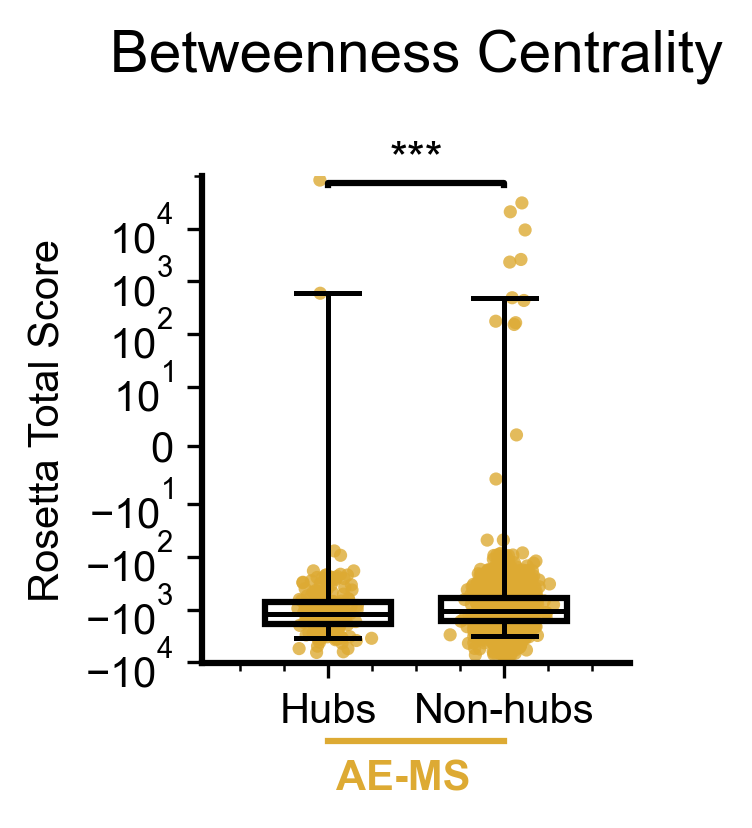

In [13]:
import matplotlib.ticker as ticker
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals   = [ms_hub_vals, ms_nothub_vals]
group_colors = [MS_COLOR,    MS_COLOR]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]

for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Hubs", "Non-hubs"],
    positions=[1, 1.7],   
    widths=0.5,             
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
#ax.set_yscale("log")
#ax.set_ylim(1, 1e7)

ax.set_ylabel("Rosetta Total Score")
ax.set_title("Betweenness Centrality")

# === SYMLOG SCALE LIKE IN CODE 2 ===
ax.set_yscale('symlog', linthresh=10)  # linear between -10 and +10

# Nice scientific ticks like in Rosetta plots
ax.set_yticks([-10000, -1000, -100, -10, 0, 10, 100, 1000, 10000])
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Optional: minor ticks for better look (cleaner)
ax.minorticks_on()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(ms_hub_vals.min(), ms_nothub_vals.min())
y_max = max(ms_hub_vals.max(), ms_nothub_vals.max())
ax.set_ylim(y_min * 1.2, y_max * 1.2)

# Place significance bracket at a fixed, nice height just above 0
bracket_y = y_max * 0.8  # you can adjust: -1, -3, -5 depending on taste
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "***")

# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.16, -0.16],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)
ax.text(
    1.3, -0.20, "AE-MS",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}supp2-3.svg")
plt.show()

In [14]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid large memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

def clean_values(s):
    return s.replace([np.inf, -np.inf], np.nan).dropna()

# Filter for proteins with 'meltome-fit-R2' > 0.9 and Only remove inf/nan — DO NOT require > 0
ms_hub_vals = ms_hubs[ms_hubs['meltome-fit-R2'] > 0.9]["meltome-melting-point"]\
    .replace([np.inf, -np.inf], np.nan).dropna()

ms_nothub_vals = ms_nothub[ms_nothub['meltome-fit-R2'] > 0.9]["meltome-melting-point"]\
    .replace([np.inf, -np.inf], np.nan).dropna()
# Groups: (label, data, color)
groups = [
    ("MS hubs",      ms_hub_vals,     MS_COLOR),
    ("MS non-hubs",  ms_nothub_vals,  MS_COLOR),
]

# -------------------------------------------------------
# 4. Compute bootstrapped medians + CIs
# -------------------------------------------------------
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 71579.48it/s]


MS hubs: median=48.60, 95% CI=(47.54, 49.05), n=177)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:23<00:00, 42994.54it/s]

MS non-hubs: median=49.03, 95% CI=(48.71, 49.32), n=1107)


In [15]:
# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on meltome-melting-point ===")

print("\nMS hubs vs MS non-hubs")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on meltome-melting-point ===

MS hubs vs MS non-hubs
n(hubs) = 177, n(non-hubs) = 1107
median(hubs) = 48.60, median(non-hubs) = 49.03
U = 88551.50, p = 0.03979


/tmp/ipykernel_17906/2466925704.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


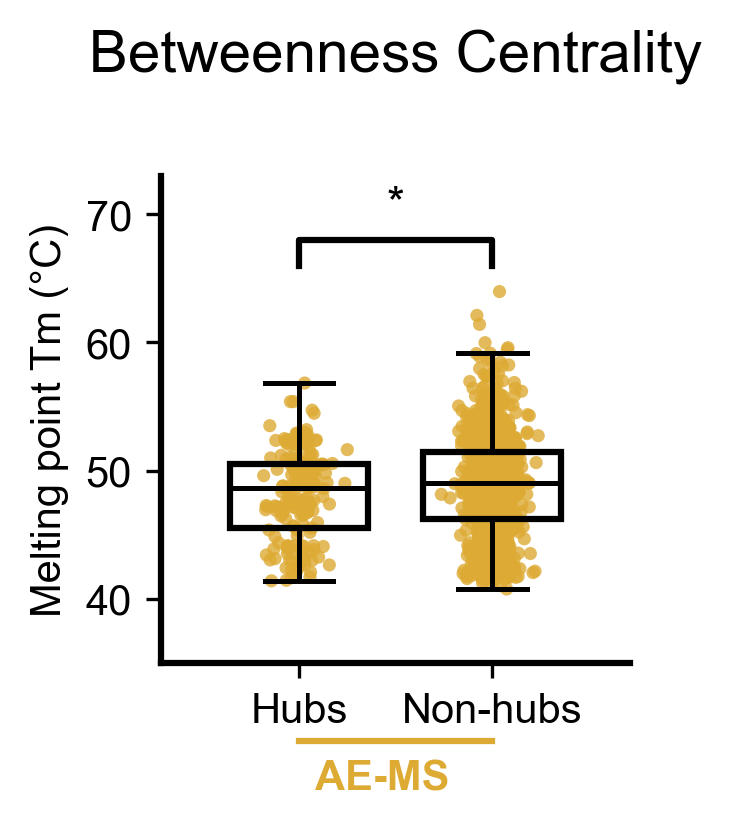

In [16]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 2.0
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top + 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals   = [ms_hub_vals, ms_nothub_vals]
group_colors = [MS_COLOR,    MS_COLOR]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]

for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Hubs", "Non-hubs"],
    positions=[1, 1.7],   
    widths=0.5,             
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
#ax.set_yscale("log")
#ax.set_ylim(1, 1e7)

ax.set_ylabel("Melting point Tm (°C)")
ax.set_title("Betweenness Centrality")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = 35     # a little below the real minimum
y_max = 73     # enough headroom for the bracket
ax.set_ylim(y_min, y_max)
ax.set_yticks([40, 50, 60, 70])          # ← forces exactly these ticks
ax.set_yticklabels([40, 50, 60, 70])

# Place significance bracket at a fixed, nice height just above 0
bracket_y = 66
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "*")

# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

# AE-MS group label under x-axis
ax.plot(
    [1.0, 1.7], [-0.16, -0.16],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)
ax.text(
    1.3, -0.20, "AE-MS",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUT_PATH}supp2-4.svg")
plt.show()